In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
from decimal import Decimal

import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy.table import Table
from gammapy.data import Observation, observatory_locations, EventList
from gammapy.datasets import MapDataset, MapDatasetEventSampler, FluxPointsDataset
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, ExcessMapEstimator
from gammapy.estimators import FluxPointsEstimator
from gammapy.estimators.utils import resample_energy_edges
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, RingBackgroundMaker, SafeMaskMaker
from gammapy.datasets import MapDataset, MapDatasetOnOff
from gammapy.makers import MapDatasetMaker, WobbleRegionsFinder
from gammapy.maps import MapAxis, RegionNDMap, WcsGeom, Map, TimeMapAxis
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ConstantSpectralModel,
    FoVBackgroundModel,
    LightCurveTemplateTemporalModel,
    Models,
    PointSpatialModel,
    PowerLawSpectralModel,
    LogParabolaSpectralModel,
    SkyModel,
)
from regions import PointSkyRegion, CircleSkyRegion

from IPython.display import display
from gammapy.data import DataStore
from gammapy.datasets import (
    Datasets,
    FluxPointsDataset,
    SpectrumDataset,
    SpectrumDatasetOnOff,
)
from gammapy.estimators import FluxPointsEstimator
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
    FoVBackgroundMaker
)
from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ExpCutoffPowerLawSpectralModel,
    SkyModel,
    create_crab_spectral_model,
    PiecewiseNormSpectralModel,
    PowerLawNormSpectralModel,
    LogParabolaSpectralModel,
)

from gammapy.visualization import plot_spectrum_datasets_off_regions, plot_distribution

import warnings

In [2]:
import yaml

def read_yaml(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

In [3]:
parfile = "./ASTRI_quicklook_analysis_parfile.yaml"
global_parameters = read_yaml(parfile)

In [4]:
global_parameters

{'OUTPUT_RESULTS': {'output_dir': './quick-look_scientific_analysis',
  'theta2_output_dir': 'theta2',
  'source_detection_output_dir': 'source_detection',
  '1d_spec_analysis_output_dir': '1D_spectral_analysis',
  'lightcurve_analysis_output_dir': 'lightcurve_analysis'},
 'DATA_ORIGIN': {'telescope': 'ASTRI-1',
  'longitude': -16.50797,
  'latitude': 28.30102},
 'INPUT_DATA': {'input_EVT3': ['/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/'],
  'input_IRF3': ['/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/']},
 'TARGET': {'target_name': 'Crab',
  'coord1': 83.63309,
  'coord2': 22.01449,
  'frame': 'icrs'},
 'EXCLUSION_REGIONS': {'source': [],
  'src_coord1': ['ra_coord_src1', 'ra_coord_src2'],
  'src_coord2': ['dec_coord_src1', 'dec_coord_src2'],
  'src_radius': ['on_reg_src1', 'on_reg_src2'],
  'frame': ['frame_src1', 'frame_src1']},
 'RUN_SELECTION': {'offset_max': 3,
  'zenith_min': 0,
  'zenith_max': 30,
  'azimuth_min': 0,
  'azimuth_max': 360,
  'tstart': 0,
  'tstop':

In [5]:
output_dir = global_parameters['OUTPUT_RESULTS']['output_dir']
output_dir_notebook = global_parameters['OUTPUT_RESULTS']['source_detection_output_dir']
Path(output_dir).mkdir(parents=True, exist_ok=True)
Path(output_dir).joinpath(output_dir_notebook).mkdir(parents=True, exist_ok=True)

## Load the ASTRI data

In [6]:
import glob, os, pathlib, itertools

target_name = global_parameters["TARGET"]["target_name"]

input_filenames = []
for folder in global_parameters['INPUT_DATA']['input_EVT3']:
    input_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0201_*.fits.gz')))
input_filenames = tuple(itertools.chain.from_iterable(input_filenames))

irf_filenames = []
for folder in global_parameters['INPUT_DATA']['input_IRF3']:
    irf_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0502_*.fits.gz')))
irf_filenames = tuple(itertools.chain.from_iterable(irf_filenames))

print(f"The number of runs is {len(input_filenames)}; the number of IRF is {len(irf_filenames)}.")
if len(input_filenames) != len(irf_filenames):
    warnings.warn("The number of runs is not compatible with the available IRFs! PLEASE CHECK!")
else:
    print("Run and available IRFs are compatible!")

datastore = DataStore.from_events_files(np.sort(input_filenames), irfs_paths=np.sort(irf_filenames))
datastore.hdu_table.write("hdu-index.fits.gz", overwrite=True)
datastore.obs_table.write("obs-index.fits.gz", overwrite=True)

The number of runs is 49; the number of IRF is 49.
Run and available IRFs are compatible!


In [ ]:
telescope_name = global_parameters["DATA_ORIGIN"]["telescope"]
target_name = global_parameters["TARGET"]["target_name"]
obs_date = datastore.obs_table[0]["EVENTS_FILENAME"].split("/")[-1][0:8]

In [8]:
import json

with open(f'{output_dir}/{output_dir_notebook}/source_detection_parfile_summary_{obs_date}_{telescope_name}_{target_name}.txt', 'w') as file:
    file.write(json.dumps(global_parameters))

In [9]:
datastore.obs_table

OBS_ID,TSTART,TSTOP,ONTIME,LIVETIME,DEADC,TELESCOP,RA_PNT,DEC_PNT,GLON_PNT,GLAT_PNT,DATE-OBS,TIME-OBS,DATE-END,TIME-END,N_TELS,OBJECT,EVENTS_FILENAME,EVENT_COUNT,CALDB,IRF,IRF_FILENAME,MJDREFI,MJDREFF,TIMEUNIT,TIMESYS,TIMEREF
,s,s,s,s,,,deg,deg,deg,deg,,,,,,,,,,,,,,,,
int64,float64,float64,float64,float64,int64,str8,float64,float64,float64,float64,str13,str13,str13,str13,int64,str1,str118,int64,str13,str13,str118,int64,float64,str1,str2,str5
433001063,155349291.0,155351273.0,1980.0,1980.0,1,ASTRI-MA,83.089,22.015,184.28465813541644,-6.209592176779089,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241202_MA_Crab_W0.50p180_00000433_R_001063_0201_cc11.lv3.fits.gz,29756,NOT AVAILABLE,NOT AVAILABLE,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241202_MA_Crab_W0.50p180_00000433_R_001063_0502_cc11.lv3.fits.gz,58849,0.00080074,s,TT,LOCAL
486001135,155522354.0,155523782.0,1426.0,1426.0,1,ASTRI-MA,83.62901,22.515,184.1307193418319,-5.519450498857071,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241204_MA_Crab_W0.50p090_00000486_R_001135_0201_cc11.lv3.fits.gz,21402,NOT AVAILABLE,NOT AVAILABLE,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241204_MA_Crab_W0.50p090_00000486_R_001135_0502_cc11.lv3.fits.gz,58849,0.00080074,s,TT,LOCAL
487001136,155524659.0,155526474.0,1813.0,1813.0,1,ASTRI-MA,83.63,21.515,184.98018075705582,-6.054013078484494,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241204_MA_Crab_W0.50p270_00000487_R_001136_0201_cc11.lv3.fits.gz,28041,NOT AVAILABLE,NOT AVAILABLE,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241204_MA_Crab_W0.50p270_00000487_R_001136_0502_cc11.lv3.fits.gz,58849,0.00080074,s,TT,LOCAL
488001137,155526554.0,155528374.0,1818.0,1818.0,1,ASTRI-MA,84.16801,22.015,184.8229398603431,-5.364684101784981,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241204_MA_Crab_W0.50p000_00000488_R_001137_0201_cc11.lv3.fits.gz,28497,NOT AVAILABLE,NOT AVAILABLE,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241204_MA_Crab_W0.50p000_00000488_R_001137_0502_cc11.lv3.fits.gz,58849,0.00080074,s,TT,LOCAL
507001172,155612979.0,155614787.0,1806.0,1806.0,1,ASTRI-MA,84.16801,22.015,184.8229398603431,-5.364684101784981,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241205_MA_Crab_W0.50p000_00000507_R_001172_0201_cc11.lv3.fits.gz,26534,NOT AVAILABLE,NOT AVAILABLE,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241205_MA_Crab_W0.50p000_00000507_R_001172_0502_cc11.lv3.fits.gz,58849,0.00080074,s,TT,LOCAL
553001221,155789041.0,155790879.0,1836.0,1836.0,1,ASTRI-MA,84.16801,22.015,184.8229398603431,-5.364684101784981,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241207_MA_Crab_W0.50p000_00000553_R_001221_0201_cc11.lv3.fits.gz,30423,NOT AVAILABLE,NOT AVAILABLE,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241207_MA_Crab_W0.50p000_00000553_R_001221_0502_cc11.lv3.fits.gz,58849,0.00080074,s,TT,LOCAL
554001222,155790928.0,155792742.0,1812.0,1812.0,1,ASTRI-MA,83.089,22.015,184.28465813541644,-6.209592176779089,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241207_MA_Crab_W0.50p180_00000554_R_001222_0201_cc11.lv3.fits.gz,31263,NOT AVAILABLE,NOT AVAILABLE,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241207_MA_Crab_W0.50p180_00000554_R_001222_0502_cc11.lv3.fits.gz,58849,0.00080074,s,TT,LOCAL
612001388,157502127.0,157503026.0,897.0,897.0,1,ASTRI-MA,84.16801,22.015,184.8229398603431,-5.364684101784981,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,NOT AVAILABLE,1,,/mnt/e/ASTRI_Backup/20260127_HandsOn/Data/LV3/cc11/20241227_MA_Crab_W0.50p000_00000612_R_001388_0201_cc11.

## Create AZ/ZD columns in the datastore for each run

In [10]:
ev_header = Table.read(datastore.obs_table["EVENTS_FILENAME"][0], hdu=1)
meta = ev_header.meta
loc = EarthLocation(
            lat=global_parameters['DATA_ORIGIN']['latitude'],
            lon=global_parameters['DATA_ORIGIN']['longitude'],
            # height = (row["TELZ"] + OBSLEV)*u.m
        )

mjdtime = ( ((datastore.obs_table["TSTART"] + datastore.obs_table["TSTOP"])/2).to("d") 
           + (datastore.obs_table["MJDREFI"] + datastore.obs_table["MJDREFF"]) * u.d )
observing_time = Time(mjdtime, format="mjd", scale="tt")  

altazframe = AltAz(location=loc, obstime=observing_time)
datastore.obs_table["DATE-OBS"] = observing_time.isot 
coord = SkyCoord(datastore.obs_table["RA_PNT"], datastore.obs_table["DEC_PNT"], unit="deg", frame="icrs")
coord_altaz = coord.transform_to(altazframe)

datastore.obs_table["AZ_PNT"] = coord_altaz.az.deg * u.deg
datastore.obs_table["ZD_PNT"] = coord_altaz.zen.deg * u.deg

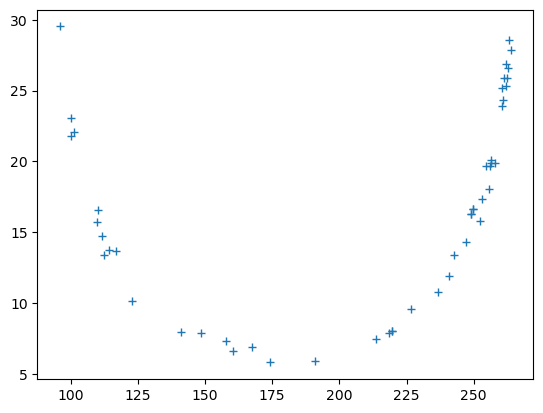

In [11]:
plt.plot(datastore.obs_table["AZ_PNT"], datastore.obs_table["ZD_PNT"], "+")

In [12]:
print(min(datastore.obs_table["AZ_PNT"]))
print(min(datastore.obs_table["ZD_PNT"]))
print(max(datastore.obs_table["AZ_PNT"]))
print(max(datastore.obs_table["ZD_PNT"]))

96.01643805443442
5.793393842940176
263.84431147921526
29.5304943549504


## Select runs according to selection criteria

In [13]:
target_position = SkyCoord(ra=global_parameters['TARGET']['coord1'], 
                           dec=global_parameters['TARGET']['coord2'], 
                           unit="deg", 
                           frame=global_parameters['TARGET']['frame'])
target_name = global_parameters['TARGET']['target_name']

selection_offset = dict(type='sky_circle',
                lon=target_position.ra.deg,
                lat=target_position.dec.deg,
                frame="icrs",
                radius=Angle(global_parameters['RUN_SELECTION']['offset_max'], 'deg')
                )

value_range_zen = Angle([global_parameters['RUN_SELECTION']['zenith_min'], 
                         global_parameters['RUN_SELECTION']['zenith_max']], 'deg')
selection_zen = dict(type='par_box', variable='ZD_PNT', value_range=value_range_zen)

value_range_az = Angle([global_parameters['RUN_SELECTION']['azimuth_min'], 
                     global_parameters['RUN_SELECTION']['azimuth_max']], 'deg')
selection_az = dict(type='par_box', variable='AZ_PNT', value_range=value_range_az)

value_range_time = np.array([global_parameters['RUN_SELECTION']['tstart'],
                             global_parameters['RUN_SELECTION']['tstop']], float) * u.s
selection_time = dict(type='par_box', variable='TSTART', value_range=value_range_time)

select_obs = datastore.obs_table.select_observations([selection_offset, selection_zen, selection_az, selection_time])
selected_obsid = select_obs["OBS_ID"]

In [14]:
#select_obs

In [ ]:
print(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n")
print(f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n")
print(f"The total runs are {len(select_obs['OBS_ID'])}. \n")

The mean exposure of the runs is 1933.6122448979593 s 

The total exposure time is 26.31861111111111 h 

The total runs are 49. These are the selected ObsID: 
   OBS_ID  
----------
 433001063
 486001135
 487001136
 488001137
 507001172
 553001221
 554001222
 612001388
 619001403
 620001404
       ...
 985001976
 998001994
 999001995
1007002010
1008002011
1015002025
1041002054
1042002055
1056002075
1064002087
Length = 49 rows 



In [16]:
file_path = Path(f"{output_dir}/{output_dir_notebook}/source_detection_summary_table_{obs_date}_{telescope_name}_{target_name}.txt")
with file_path.open('w') as file:
    file.write(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n\n" +
               f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n\n" +
               f"The total runs are {len(select_obs['OBS_ID'])}. These are the selected ObsID: \n {select_obs['OBS_ID']}"
              )

## Load the observations

In [17]:
observations = datastore.get_observations(obs_id=selected_obsid)

In [23]:
i=0
av_irf = observations[0].available_irfs
area_eff_i = observations[i].aeff
edisp_i = observations[i].edisp
irf_psf_i = observations[i].psf
bkg_i = observations[i].bkg

gti_i = observations[i].gti

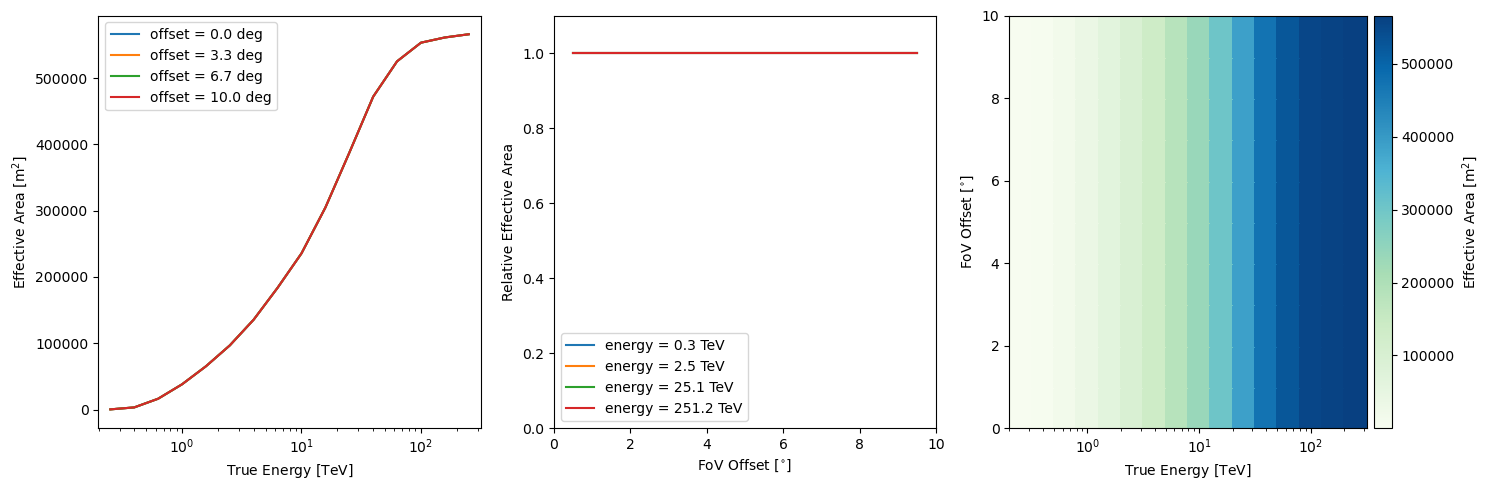

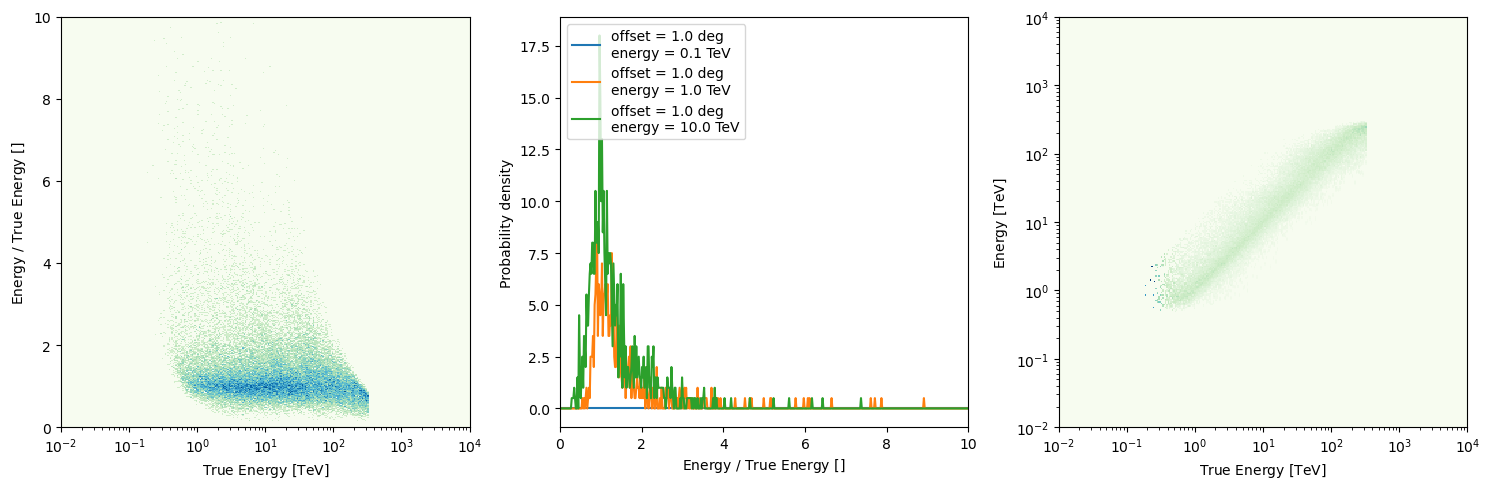

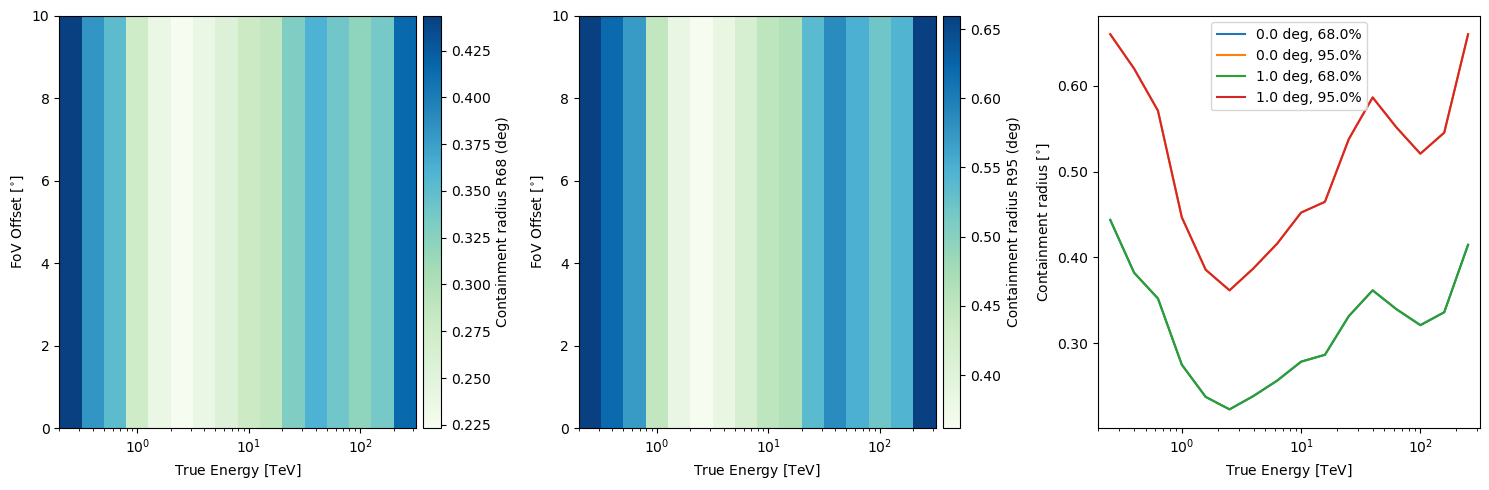

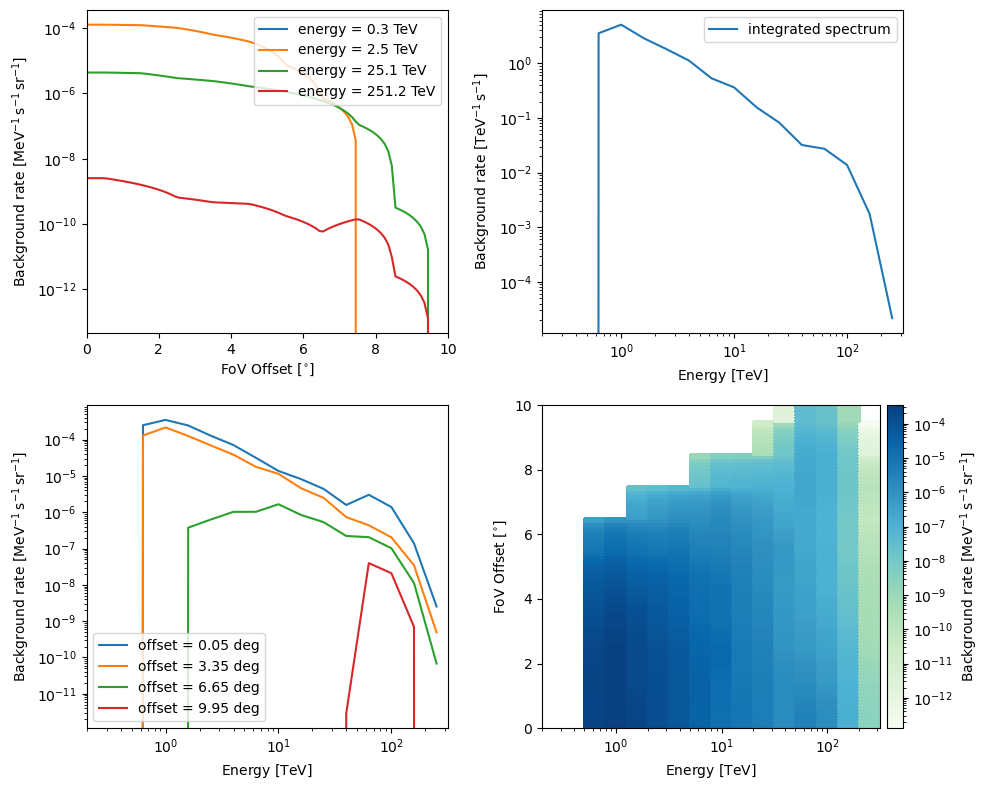

In [24]:
area_eff_i.peek()
edisp_i.peek()
irf_psf_i.peek()
bkg_i.peek()

In [18]:
#print(observations[0].events.table)

In [19]:
irf_psf = observations[0].psf
#observations[0].aeff

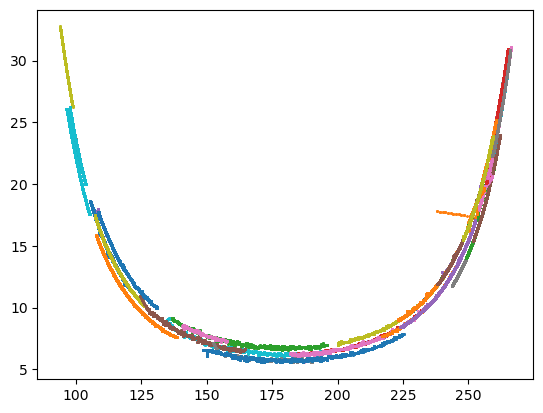

In [20]:
for obs in observations:
       plt.plot(obs.events.table["AZ"], obs.events.table["ZD"], "o", markersize=0.5)

plt.savefig(f"{output_dir}/{output_dir_notebook}/source_detection_zd_az_runs_distribution_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')
plt.savefig(f"{output_dir}/{output_dir_notebook}/source_detection_zd_az_runs_distribution_{obs_date}_{telescope_name}_{target_name}.png", bbox_inches='tight')

# Choose the BKG type:

In [21]:
bkg = global_parameters['SOURCE_DET_PARAM']['bkg_src_detection']

## Data-reduction: make the Dataset(s)

<WCSAxes: >

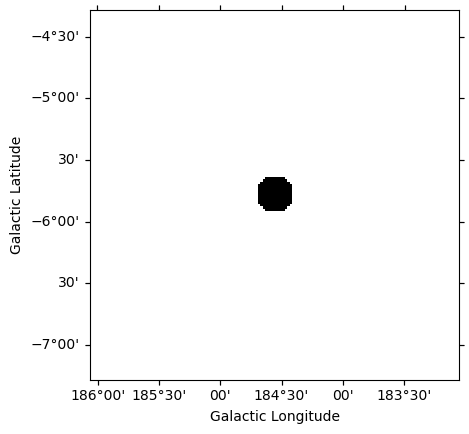

In [22]:
width = global_parameters['DATASET_SETTINGS']['width']
binsz = global_parameters['DATASET_SETTINGS']['binsz']
radius= np.sqrt(global_parameters['DATASET_SETTINGS']['on_radius'])

on_region_radius = Angle(radius * u.deg)
on_region = CircleSkyRegion(center=target_position, radius=on_region_radius)

npix = int(width/binsz)

exclusion_region = [CircleSkyRegion(
    center=target_position,
    radius=radius * u.deg,
    )]

for i, src in enumerate(global_parameters['EXCLUSION_REGIONS']['source']):
    src_position = SkyCoord(ra=global_parameters['EXCLUSION_REGIONS']['src_coord1'][i], 
                            dec=global_parameters['EXCLUSION_REGIONS']['src_coord2'][i], 
                            unit="deg", 
                            frame=global_parameters['EXCLUSION_REGIONS']['frame'][i])
    
    src_exclusion_region = CircleSkyRegion(
                                    center=src_position,
                                    radius=global_parameters['EXCLUSION_REGIONS']['src_radius'][i] * u.deg,
                                    )
    exclusion_region.append(src_exclusion_region)

geom_excl = WcsGeom.create(
    npix=(npix, npix), binsz=binsz, skydir=target_position.galactic, proj="TAN", frame="galactic"
)

exclusion_mask = ~geom_excl.region_mask(exclusion_region)
exclusion_mask.plot()

In [24]:
e_min, e_max = (global_parameters['DATASET_SETTINGS']['energy_reco_min'] * u.TeV, 
                global_parameters['DATASET_SETTINGS']['energy_reco_max'] * u.TeV) 

energy_axis = MapAxis.from_energy_bounds(
                    e_min, e_max, 
                    nbin=global_parameters['DATASET_SETTINGS']['nbin_reco'], 
                    per_decade=False, unit="TeV", name="energy") 

# Reduced IRFs are defined in true energy (i.e. not measured energy).
energy_axis_true = MapAxis.from_energy_bounds(
                    global_parameters['DATASET_SETTINGS']['energy_true_min'], 
                    global_parameters['DATASET_SETTINGS']['energy_true_max'], 
                    nbin=global_parameters['DATASET_SETTINGS']['nbin_true'], 
                    per_decade=False, unit="TeV", name="energy_true" 
                    )

In [25]:
geom = WcsGeom.create(
    skydir=(target_position.galactic.l.deg , target_position.galactic.b.deg),
    binsz=binsz,
    width=(width, width),
    frame="galactic",
    proj="CAR",
    axes=[energy_axis],
)

stacked = MapDataset.create(
    geom=geom, energy_axis_true=energy_axis_true, name="my-dataset"
)

dataset_maker = MapDatasetMaker()

if bkg == "FoV":
    spectral_model = PowerLawNormSpectralModel()
    spectral_model.norm.frozen = False
    # spectral_model.tilt.frozen = True
    spectral_model.tilt.frozen = False

    maker_fov = FoVBackgroundMaker(method="fit", 
                                   exclusion_mask=exclusion_mask,
                                    spectral_model=spectral_model)

if bkg == "ring_background":
    maker_fov = RingBackgroundMaker(r_in=global_parameters['SOURCE_DET_PARAM']['r_in'] * u.deg, 
                                    width=global_parameters['SOURCE_DET_PARAM']['width'] * u.deg,
                                    exclusion_mask=exclusion_mask,
                                    )

In [26]:
offset_max = global_parameters['SAFEMASK_DATSET']['offset_max'] * u.deg
safe_mask_masker = SafeMaskMaker(
#    methods=["offset-max", "aeff-max"], aeff_percent=5, offset_max=offset_max
    methods=["aeff-default","offset-max"], offset_max=offset_max
 )

In [27]:
Norm_bkg = []
Time_obs = []
for i, observation in enumerate(observations):
        dataset = dataset_maker.run(stacked.copy(name=str(observation.obs_id)), observation)
        dataset = safe_mask_masker.run(dataset, observation)
        dataset = maker_fov.run(dataset)
        stacked.stack(dataset)

        if bkg == "FoV":
            Norm_bkg.append(dataset.background_model.spectral_model.norm.value)
            Time_obs.append((observation.gti.time_start.mjd + observation.gti.time_start.mjd)[0] / 2)
            print(
                    f"{i+1} of {len(observations)}, Background norm obs {observation.obs_id}: {dataset.background_model.spectral_model.norm.value:.2f}"
                )

        if bkg == "ring_background":
            print(f"{i+1} of {len(observations)}")

No default upper safe energy threshold defined for obs 433001063
No default lower safe energy threshold defined for obs 433001063


1 of 49


No default upper safe energy threshold defined for obs 486001135
No default lower safe energy threshold defined for obs 486001135


2 of 49


No default upper safe energy threshold defined for obs 487001136
No default lower safe energy threshold defined for obs 487001136


...

47 of 49


No default upper safe energy threshold defined for obs 1056002075
No default lower safe energy threshold defined for obs 1056002075


48 of 49


No default upper safe energy threshold defined for obs 1064002087
No default lower safe energy threshold defined for obs 1064002087


49 of 49


In [28]:
#stacked = stacked.downsample(factor=2)

In [29]:
stacked

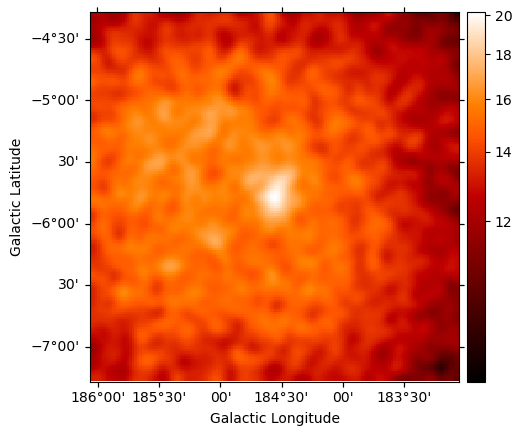

In [30]:
ax = stacked.counts.sum_over_axes().smooth(0.05 * u.deg).plot(stretch="sqrt", cmap="gist_heat", add_cbar=True)

/tmp/ipykernel_161072/4036170731.py:4: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/home/francesco/anaconda3/envs/gammapy-2.0.1/lib/python3.12/site-packages/regions/shapes/circle.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Circle(xy=xy, radius=radius, **mpl_kwargs)


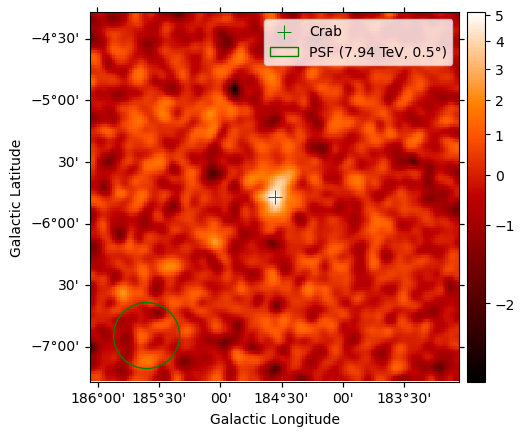

In [31]:
excess = stacked.excess.sum_over_axes()
ax = excess.smooth("0.04 deg").plot(stretch="sqrt", cmap="gist_heat", add_cbar=True)

ax.scatter(
        target_position.icrs.ra,
        target_position.icrs.dec,
        transform=ax.get_transform("icrs"),
        color="green",
        edgecolor="b",
        marker="+",
        s=100,
        lw=0.7,
        label=target_name
    )

nrg = np.sqrt(stacked.geoms["geom"].axes["energy"].edges[0] * stacked.geoms["geom"].axes["energy"].edges[-1])
psf = irf_psf.containment_radius(energy_true=nrg, offset=0.5*u.deg, fraction=0.68)
siz = np.sqrt(global_parameters['DATASET_SETTINGS']['width']**2 * 2) / 2 - psf.value * 2.2
psf_pos = target_position.directional_offset_by(195*u.deg, siz*u.deg)
circle = RegionGeom.create(f"icrs;circle({psf_pos.icrs.ra.deg}, {psf_pos.icrs.dec.deg}, {psf.value})")
circle.plot_region(ax=ax, label=f"PSF ({np.round(nrg.value, 2)} TeV, 0.5°)", color="green")

ax.legend()

plt.savefig(f"{output_dir}/{output_dir_notebook}/source_detection_excess_map_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

## TS MAP

/tmp/ipykernel_161072/1303402246.py:19: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[i,j].scatter(
/home/francesco/anaconda3/envs/gammapy-2.0.1/lib/python3.12/site-packages/regions/shapes/circle.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Circle(xy=xy, radius=radius, **mpl_kwargs)
/tmp/ipykernel_161072/1303402246.py:19: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[i,j].scatter(
/home/francesco/anaconda3/envs/gammapy-2.0.1/lib/python3.12/site-packages/regions/shapes/circle.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Circle(xy=xy, radius=radius, **mpl_kwargs)
/t

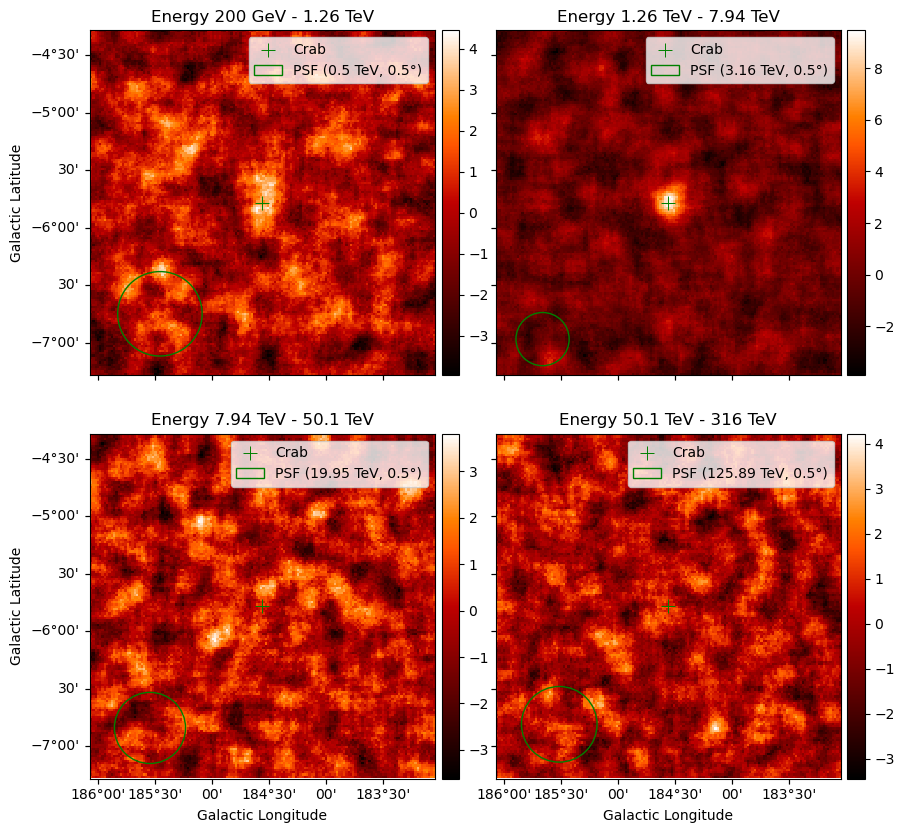

In [ ]:
energy_edges = energy_axis.downsample(4).edges 
nrg = np.sqrt(energy_edges[:-1]*energy_edges[1:])

estimator = ExcessMapEstimator(
    correlation_radius="0.1 deg",
    selection_optional="all",
    energy_edges=energy_edges,
)

result = estimator.run(stacked)
ax = result["sqrt_ts"].plot_grid(
    figsize=(10, 10), cmap="gist_heat", add_cbar=True, 
    ncols=2
)

k = 0
for i in np.arange(np.shape(ax)[0]):
    for j in np.arange(np.shape(ax)[1]):
        ax[i,j].scatter(
                target_position.icrs.ra,
                target_position.icrs.dec,
                transform=ax[i,j].get_transform("icrs"),
                color="green",
                edgecolor="b",
                marker="+",
                s=100,
                lw=0.7,
                label=target_name
            )

        psf = irf_psf.containment_radius(energy_true=nrg[k], offset=0.5*u.deg, fraction=0.68)
        siz = np.sqrt(global_parameters['DATASET_SETTINGS']['width']**2 * 2) / 2 - psf.value * 2.2
        psf_pos = target_position.directional_offset_by(195*u.deg, siz*u.deg)
        
        circle = RegionGeom.create(f"icrs;circle({psf_pos.icrs.ra.deg}, {psf_pos.icrs.dec.deg}, {psf.value})")
        circle.plot_region(ax=ax[i,j], label=f"PSF ({np.round(nrg[k].value, 2)} TeV, 0.5°)", color="green")
        
        ax[i,j].legend()
        k += 1

plt.savefig(f"{output_dir}/{output_dir_notebook}/source_detection_energy_resolved_maps_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

In [33]:
stacked_copy = stacked.copy(stacked.name)

geom_3D_excl = exclusion_mask.geom.to_cube([stacked.counts.geom.axes["energy"]])
mask_fit_final = Map.from_geom(stacked_copy.counts.geom)
exclusion_mask_reprojected = exclusion_mask.interp_to_geom(
    geom=stacked_copy.counts.geom, 
    method="nearest"
)

stacked_copy.mask_fit = exclusion_mask_reprojected

/tmp/ipykernel_161072/3030614227.py:22: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax0.scatter(
/home/francesco/anaconda3/envs/gammapy-2.0.1/lib/python3.12/site-packages/regions/shapes/circle.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Circle(xy=xy, radius=radius, **mpl_kwargs)


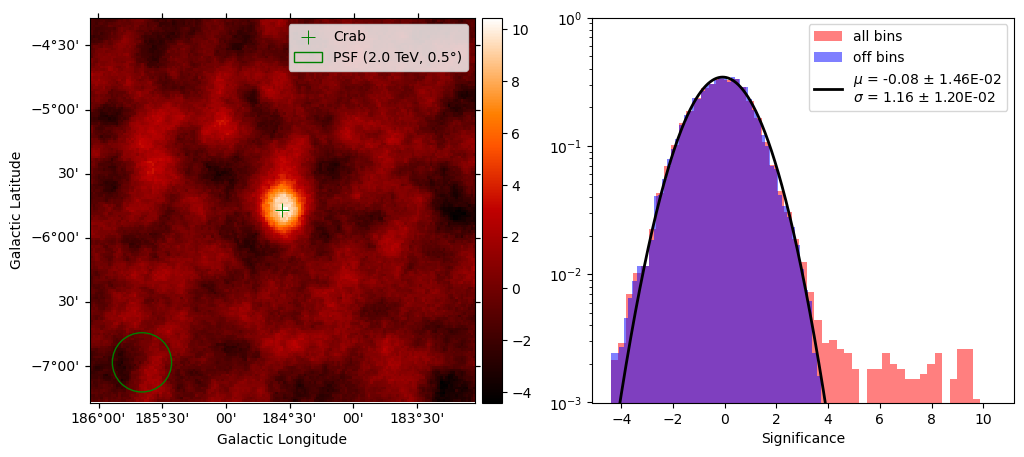

In [34]:
excess_estimator_integrated = ExcessMapEstimator(
    correlation_radius=global_parameters['SOURCE_DET_PARAM']['correlation_radius'], selection_optional="all", n_sigma=1,
    n_sigma_ul=3,
    energy_edges=[global_parameters['SOURCE_DET_PARAM']['energy_min'], 
                  global_parameters['SOURCE_DET_PARAM']['energy_max']] * u.TeV,
    correlate_off=True
)
excess_integrated = excess_estimator_integrated.run(stacked)

significance_map = excess_integrated["sqrt_ts"]

excess_integrated_excl = excess_estimator_integrated.run(stacked_copy)
significance_map_off = excess_integrated_excl["sqrt_ts"]

fig = plt.figure(figsize=(12, 5))
wcs = significance_map.geom.wcs
ax0 = fig.add_subplot(1, 2, 1, projection=wcs)
ax1 = fig.add_subplot(1, 2, 2)
#excess_integrated["sqrt_ts"].plot(add_cbar=True, cmap="viridis")
excess_integrated["sqrt_ts"].plot(add_cbar=True, cmap="gist_heat", ax=ax0)

ax0.scatter(
        target_position.icrs.ra,
        target_position.icrs.dec,
        transform=ax0.get_transform("icrs"),
        color="green",
        edgecolor="b",
        marker="+",
        s=100,
        lw=0.7,
        label=target_name
    )

nrg = np.sqrt([global_parameters['SOURCE_DET_PARAM']['energy_min'] * global_parameters['SOURCE_DET_PARAM']['energy_max']])
psf = irf_psf.containment_radius(energy_true=nrg*u.TeV, offset=0.5*u.deg, fraction=0.68)
siz = np.sqrt(global_parameters['DATASET_SETTINGS']['width']**2 * 2) / 2 - psf.value * 2.2
psf_pos = target_position.directional_offset_by(195*u.deg, siz*u.deg)
circle = RegionGeom.create(f"icrs;circle({psf_pos.icrs.ra.deg[0]}, {psf_pos.icrs.dec.deg[0]}, {psf[0].value})")
circle.plot_region(ax=ax0, label=f"PSF ({np.round(nrg, 2)[0]} TeV, 0.5°)", color="green")

enr_min = global_parameters['SOURCE_DET_PARAM']['energy_min']
enr_max = global_parameters['SOURCE_DET_PARAM']['energy_max']

ax0.legend()

kwargs_axes = {"xlabel": "Significance", "yscale": "log", "ylim": (1e-3, 1)}
ax1, _ = plot_distribution(
    significance_map,
    kwargs_hist={
        "density": True,
        "alpha": 0.5,
        "color": "red",
        "label": "all bins",
        "bins": 51,
    },
    kwargs_axes=kwargs_axes,
    ax=ax1
)

ax1, res = plot_distribution(
    significance_map_off,
    func="norm",
    kwargs_hist={
        "density": True,
        "alpha": 0.5,
        "color": "blue",
        "label": "off bins",
        "bins": 51,
    },
    kwargs_axes=kwargs_axes,
    ax = ax1
)

plt.savefig(f"{output_dir}/{output_dir_notebook}/source_detection_significance_{global_parameters['SOURCE_DET_PARAM']['energy_min']}-{global_parameters['SOURCE_DET_PARAM']['energy_max']}TeV_maps_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')
plt.savefig(f"{output_dir}/{output_dir_notebook}/source_detection_significance_{global_parameters['SOURCE_DET_PARAM']['energy_min']}-{global_parameters['SOURCE_DET_PARAM']['energy_max']}TeV_maps_{obs_date}_{telescope_name}_{target_name}.png", bbox_inches='tight')

value,x,y,ra,dec
,,,deg,deg
float64,int64,int64,float64,float64
10.461,76,75,83.62488,22.04518


/tmp/ipykernel_161072/3124195135.py:16: UserWarning: You passed a edgecolor/edgecolors ('b') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax0.scatter(
/home/francesco/anaconda3/envs/gammapy-2.0.1/lib/python3.12/site-packages/regions/shapes/circle.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return Circle(xy=xy, radius=radius, **mpl_kwargs)


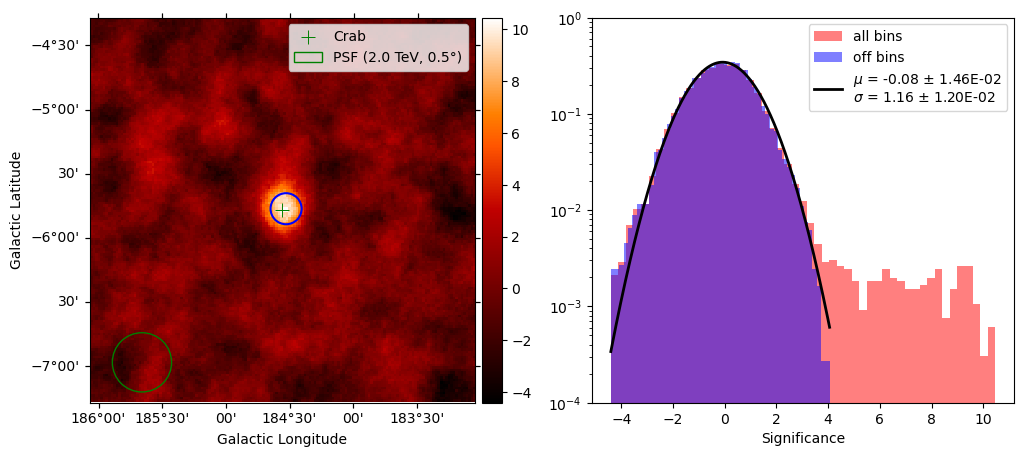

In [35]:
from gammapy.estimators.utils import find_peaks

sources = find_peaks(excess_integrated["sqrt_ts"], 
                     threshold=global_parameters['SOURCE_DET_PARAM']['sig_threshold'], 
                     min_distance=global_parameters['SOURCE_DET_PARAM']['min_distance'])
nsou = len(sources)
display(sources)

# Plot sources on top of significance sky image
fig = plt.figure(figsize=(12, 5))
wcs = significance_map.geom.wcs
ax0 = fig.add_subplot(1, 2, 1, projection=wcs)
ax1 = fig.add_subplot(1, 2, 2)
excess_integrated["sqrt_ts"].plot(add_cbar=True, cmap="gist_heat", ax=ax0)

ax0.scatter(
        target_position.icrs.ra,
        target_position.icrs.dec,
        transform=ax0.get_transform("icrs"),
        color="green",
        edgecolor="b",
        marker="+",
        s=100,
        lw=0.7,
        label=target_name
    )

nrg = np.sqrt([global_parameters['SOURCE_DET_PARAM']['energy_min'] * global_parameters['SOURCE_DET_PARAM']['energy_max']])
psf = irf_psf.containment_radius(energy_true=nrg*u.TeV, offset=0.5*u.deg, fraction=0.68)
siz = np.sqrt(global_parameters['DATASET_SETTINGS']['width']**2 * 2) / 2 - psf.value * 2.2
psf_pos = target_position.directional_offset_by(195*u.deg, siz*u.deg)
circle = RegionGeom.create(f"icrs;circle({psf_pos.icrs.ra.deg[0]}, {psf_pos.icrs.dec.deg[0]}, {psf[0].value})")
circle.plot_region(ax=ax0, label=f"PSF ({np.round(nrg, 2)[0]} TeV, 0.5°)", color="green")

enr_min = global_parameters['SOURCE_DET_PARAM']['energy_min']
enr_max = global_parameters['SOURCE_DET_PARAM']['energy_max']

ax0.legend()

if len(sources) > 0:
    ax0.scatter(
        sources["ra"],
        sources["dec"],
        transform=ax0.get_transform("icrs"),
        color="None",
        edgecolor="b",
        marker="o",
        s=500,
        lw=1.5,
    )

kwargs_axes = {"xlabel": "Significance", "yscale": "log", "ylim": (1e-4, 1)}
ax1, _ = plot_distribution(
    significance_map,
    kwargs_hist={
        "density": True,
        "alpha": 0.5,
        "color": "red",
        "label": "all bins",
        "bins": 51,
    },
    kwargs_axes=kwargs_axes,
    ax=ax1
)

ax1, res = plot_distribution(
    significance_map_off,
    func="norm",
    kwargs_hist={
        "density": True,
        "alpha": 0.5,
        "color": "blue",
        "label": "off bins",
        "bins": 51,
    },
    kwargs_axes=kwargs_axes,
    ax = ax1
)

plt.savefig(f"{output_dir}/{output_dir_notebook}/source_detection_excess_map_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')

In [36]:
if len(sources) > 0:
    sources.rename_column('value', 'Significance')
    sources.write(f"{output_dir}/{output_dir_notebook}/source_detected_from_excess_maps_{obs_date}_{telescope_name}_{target_name}.txt", format="ascii", overwrite=True)

In [37]:
if len(sources) > 0:
    src_det_position = SkyCoord(ra=sources["ra"][0], dec=sources["dec"][0], unit="deg", frame="icrs")
    target_position.separation(src_det_position).deg